In [1]:
# from autocvd import autocvd
# autocvd(num_gpus = 1, interval=1)
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '5'

import numpy as np
import matplotlib.pyplot as plt
import time 
from functools import partial  # Change this line - lowercase 'partial'

import jax.numpy as jnp
import jax
from jax import jit
from jax.scipy.special import logsumexp


# jax.config.update("jax_enable_x64", True)
from jax.sharding import Mesh, PartitionSpec, NamedSharding         #IMPORT NEEDED FOR AUTOMATIC PARALLELISM
from jax.experimental import shard_map



import pandas as pd
import seaborn as sns
from chainconsumer import Chain, ChainConsumer, Truth



from odisseo import construct_initial_state
from odisseo.dynamics import  DIRECT_ACC_MATRIX, DIRECT_ACC_LAXMAP
from odisseo.option_classes import SimulationConfig, SimulationParams, MNParams, NFWParams, PlummerParams, PSPParams, MN_POTENTIAL, NFW_POTENTIAL, PSP_POTENTIAL
from odisseo.initial_condition import Plummer_sphere
from odisseo.time_integration import time_integration
from odisseo.units import CodeUnits
from odisseo.utils import projection_on_GD1
from astropy import units as u
import blackjax
from tqdm import tqdm


code_length = 10.0 * u.kpc
code_mass = 1e4 * u.Msun
code_time = 3 * u.Gyr
code_units = CodeUnits(code_length, code_mass, G=1, unit_time = code_time )  
N_particles = 1000

pos_com_final = jnp.array([[11.8, 0.79, 6.4]]) * u.kpc.to(code_units.code_length)
vel_com_final = jnp.array([[109.5,-254.5,-90.3]]) * (u.km/u.s).to(code_units.code_velocity)

config_sim = SimulationConfig(N_particles = N_particles,
                            return_snapshots = False, 
                            num_timesteps = 1000, 
                            external_accelerations=(NFW_POTENTIAL, MN_POTENTIAL, PSP_POTENTIAL), 
                            acceleration_scheme = DIRECT_ACC_MATRIX,
                            softening = (0.1 * u.pc).to(code_units.code_length).value,) #default values
        #the center of mass needs to be integrated backwards in time first 
config_com = config_sim._replace(N_particles=1,)

@jit
def run_simulation(rng_key, params):
    params_samples = SimulationParams(t_end = params['t_end'] * u.Gyr.to(code_units.code_time),
                        Plummer_params = PlummerParams(Mtot=params['Mtot'] * u.Msun.to(code_units.code_mass),
                                                       a = params['a_Plummer'] * u.kpc.to(code_units.code_length),),
                        NFW_params = NFWParams(Mvir=params['M_NFW'] * u.Msun.to(code_units.code_mass),
                                               r_s= params['r_s'] * u.kpc.to(code_units.code_length)),
                        MN_params = MNParams(M = params['M_MN'] * u.Msun.to(code_units.code_mass),
                                             a = params['a_MN'] * u.kpc.to(code_units.code_length),
                                            b = (0.280 * u.kpc).to(code_units.code_length).value),
                        PSP_params= PSPParams(M = 4501365375.06545 * u.Msun.to(code_units.code_mass),
                                                alpha = 1.8, 
                                                r_c = (1.9*u.kpc).to(code_units.code_length).value),  
                        G = code_units.G, )

    params_com = params_samples._replace(t_end=-params_samples.t_end,)
    mass_com = jnp.array([params_samples.Plummer_params.Mtot]) 
    
    #we construmt the initial state of the com 
    initial_state_com = construct_initial_state(pos_com_final, vel_com_final,)
    #we run the simulation backwards in time for the center of mass
    final_state_com = time_integration(initial_state_com, mass_com, config=config_com, params=params_com)
    #we calculate the final position and velocity of the center of mass
    pos_com = final_state_com[:, 0]
    vel_com = final_state_com[:, 1]

    #we construct the initial state of the Plummer sphere
    positions, velocities, mass = Plummer_sphere(key=rng_key, params=params_samples, config=config_sim)
    #we add the center of mass position and velocity to the Plummer sphere particles
    positions = positions + pos_com
    velocities = velocities + vel_com
    #initialize the initial state
    initial_state_stream = construct_initial_state(positions, velocities, )
    #run the simulation
    final_state = time_integration(initial_state_stream, mass, config=config_sim, params=params_samples)

    #projection on the GD1 stream
    stream = projection_on_GD1(final_state, code_units=code_units,)

    return stream


def stream_likelihood(model_stream, obs_stream):
    # Define bin edges and create meshgrids
    phi1_bins = jnp.linspace(-120, 70, 65)    # 64 bins
    phi2_bins = jnp.linspace(-8, 2, 33)       # 32 bins
    v1_bins = jnp.linspace(-2., 1.0, 65)      # 64 bins  
    v2_bins = jnp.linspace(-0.10, 0.10, 33)   # 32 bins
    R_bins = jnp.linspace(6, 20, 65)          # 64 bins
    vR_bins = jnp.linspace(-250, 250, 33)     # 32 bins


    # Create meshgrids for bin edges (not centers)
    PHI1, PHI2 = jnp.meshgrid(phi1_bins, phi2_bins, indexing='ij')
    V1, V2 = jnp.meshgrid(v1_bins, v2_bins, indexing='ij')
    R_GRID, VR_GRID = jnp.meshgrid(R_bins, vR_bins, indexing='ij')


            
    @jit
    def densities(stream):
        # take relevant projections from simulated stream
        x_phi = stream[:, [1,2]]   # phi1, phi2
        x_v   = stream[:, [4,5]]   # vphi1, vphi2
        x_R   = stream[:, [0,3]]   # R, v_radial

        # choose bandwidths (tune or use Silverman's rule)
        bw_phi = jnp.array([2.0, 0.5])     # example: phi1=2deg, phi2=0.5deg
        bw_v   = jnp.array([0.1, 0.01])    # example velocities
        bw_R   = jnp.array([0.5, 20.0])    # example R and vR

        # KDE densities on each meshgrid
        dens_phi = kde2d_on_grid(x_phi, PHI1, PHI2, bw_phi)
        dens_v   = kde2d_on_grid(x_v, V1, V2, bw_v)
        dens_R   = kde2d_on_grid(x_R, R_GRID, VR_GRID, bw_R)
        return dens_phi, dens_v, dens_R

    @jit
    def kde2d_on_grid(x, grid_x, grid_y, bandwidth):
        """
        Evaluate 2D Gaussian KDE on a meshgrid.

        Parameters
        ----------
        x : (N, 2) 
            Simulation data points in 2D (e.g., (phi1, phi2)).
        grid_x, grid_y : (Nx, Ny)
            Meshgrid arrays defining grid coordinates where density is evaluated.
        bandwidth : float or (2,)
            Bandwidth per dimension (std dev of Gaussian kernel).

        Returns
        -------
        dens : (Nx, Ny) 
            KDE density evaluated at grid points.
        """
        N, d = x.shape
        assert d == 2

        # Flatten grid to (G, 2)
        grid_points = jnp.stack([grid_x.ravel(), grid_y.ravel()], axis=1)  # (G,2)

        # Differences (G, N, 2)
        diff = grid_points[:, None, :] - x[None, :, :]

        # Handle bandwidth
        bw = jnp.atleast_1d(bandwidth)
        if bw.shape == (1,):
            bw = jnp.repeat(bw, 2)
        var = bw**2

        # Mahalanobis distance per dimension
        sq = (diff**2) / var  # (G,N,2)

        # log kernel for each (gridpoint, datapoint)
        logk = -0.5 * jnp.sum(sq, axis=-1) - 0.5*jnp.sum(jnp.log(2*jnp.pi*var))

        # logsumexp over datapoints
        log_dens = logsumexp(logk, axis=1) - jnp.log(N)

        dens = jnp.exp(log_dens).reshape(grid_x.shape)
        return dens

    dens_phi_target, dens_v_target, dens_R_target = densities(obs_stream)
    dens_phi, dens_v, dens_R = densities(model_stream)

    return jnp.exp(-0.1*(jnp.sum((dens_phi - dens_phi_target)**2) +
            jnp.sum((dens_v - dens_v_target)**2) +
            jnp.sum((dens_R - dens_R_target)**2)))

    




def stream_likelihood_diag(model_stream, obs_stream, obs_errors, ):
    """
    Log-likelihood of observed stars given simulated stream (diagonal covariance).
    
    Parameters
    ----------
    model_stream : (N_model, D)
    obs_stream : (N_obs, D)
    obs_errors : (N_obs, D)   # per-dimension standard deviations
    tau : float
        Stream membership fraction
    p_field : float
        Background probability density
    """
    def obs_log_prob(obs, sigma):
        def model_log_prob(model_point):
            return log_diag_multivariate_normal(obs, model_point, sigma)

        # Compute log_probs for all model points
        log_probs = jax.vmap(model_log_prob)(model_stream)
        
        # Numerically stable average: log(mean(exp(log_probs)))
        log_p_stream = jax.scipy.special.logsumexp(log_probs) - jnp.log(model_stream.shape[0])
        
        # Mixture model
        # p_total = tau * jnp.exp(log_p_stream) + (1 - tau) * p_field
        # p_total = jnp.exp(log_p_stream)
        # return jnp.log(p_total + 1e-30)
        return log_p_stream

    # Vectorize over observations
    obs_error = jnp.asarray(obs_errors).reshape((1, 6))  # (1,D)
    obs_error = jnp.repeat(obs_error, obs_stream.shape[0], axis=0)  # (N_obs,D)
    print(obs_error[0])
    logL_values = jax.vmap(obs_log_prob)(obs_stream, obs_error)
    return jnp.mean(logL_values)/1_000





true_GD1_observation_path = '/export/data/vgiusepp/odisseo_data/data_fix_position/true.npz'
observation = jnp.array(np.load(true_GD1_observation_path)['x'])
true_theta = jnp.array(np.load(true_GD1_observation_path)['theta'][:1000])

@jit
def evaluate_loglikelihood(observation, theta_1, ):

        key = jax.random.PRNGKey(0)
        # print(f"In the corrector: theta_1 shape: {theta_1.shape}, target shape: {target.shape}")
        output = run_simulation(key, theta_1)

        return stream_likelihood(model_stream=output, obs_stream=observation,)


# True parameter values (without code_units transformation)
true_params = jnp.array([
    3.0,                    # t_end (Gyr)
    10**4.05,              # Plummer Mtot (Msun) 
    8.0 * 1e-3,            # Plummer a (kpc) - converted from pc to kpc
    4.3683325e11,          # NFW Mvir (Msun)
    16.0,                  # NFW r_s (kpc)
    68_193_902_782.346756, # MN M (Msun)
    3.0,                   # MN a (kpc)
])

# Prior bounds for each parameter
prior_bounds = jnp.array([
    [0.5, 5.0],                    # t_end: 0.5 to 5 Gyr
    [10**3, 10**4.5],              # Plummer Mtot: 10^3 to 10^4.5 Msun
    [8.0 * 1e-3 * 0.25, 8.0 * 1e-3 * 2.0],  # Plummer a: 1/4 to 2x true (kpc)
    [4.3683325e11 * 0.25, 4.3683325e11 * 2.0],  # NFW Mvir: 1/4 to 2x true
    [16.0 * 0.25, 16.0 * 2.0],    # NFW r_s: 1/4 to 2x true (kpc)
    [68_193_902_782.346756 * 0.25, 68_193_902_782.346756 * 2.0],  # MN M: 1/4 to 2x true
    [3.0 * 0.25, 3.0 * 2.0],      # MN a: 1/4 to 2x true (kpc)
])  # Shape: (7, 2) for [min, max] bounds

def draw_from_prior(key):
    """Draw samples from uniform prior."""
    key, subkey = jax.random.split(key)
    u = jax.random.uniform(subkey, shape=(7,))
    
    # Transform uniform [0,1] to [min, max] for each parameter
    samples = prior_bounds[:, 0] + u * (prior_bounds[:, 1] - prior_bounds[:, 0])
    samples = {'t_end': samples[0], 'Mtot': samples[1], 'a_Plummer': samples[2], 'M_NFW': samples[3], 'r_s': samples[4], 'M_MN': samples[5], 'a_MN': samples[6]}
    return samples

@jit
def evaluate_log_prior(theta):
    """Evaluate log prior density (uniform)."""
    # Check if all parameters are within bounds 
    # theta = jnp.array([theta['t_end'], theta['Mtot'], theta['a_Plummer'], theta['M_NFW'], theta['r_s'], theta['M_MN'], theta['a_MN']])
    # in_bounds = jnp.all((theta >= prior_bounds[:, 0]) & (theta <= prior_bounds[:, 1])) 
    in_bounds = jnp.all(jnp.array([
        (theta['t_end'] >= prior_bounds[0, 0]) & (theta['t_end'] <= prior_bounds[0, 1]),
        (theta['Mtot'] >= prior_bounds[1, 0]) & (theta['Mtot'] <= prior_bounds[1, 1]),
        (theta['a_Plummer'] >= prior_bounds[2, 0]) & (theta['a_Plummer'] <= prior_bounds[2, 1]),    
        (theta['M_NFW'] >= prior_bounds[3, 0]) & (theta['M_NFW'] <= prior_bounds[3, 1]),
        (theta['r_s'] >= prior_bounds[4, 0]) & (theta['r_s'] <= prior_bounds[4, 1]),
        (theta['M_MN'] >= prior_bounds[5, 0]) & (theta['M_MN'] <= prior_bounds[5, 1]),
        (theta['a_MN'] >= prior_bounds[6, 0]) & (theta['a_MN'] <= prior_bounds[6, 1]),
    ]))
    
    # For uniform distribution: log(density) = -log(volume)
    # Volume = product of interval widths
    log_volume = jnp.sum(jnp.log(prior_bounds[:, 1] - prior_bounds[:, 0]))
    
    # Return -inf if out of bounds, -log_volume if in bounds
    return jnp.where(in_bounds, -log_volume, -jnp.inf)
    # return -log_volume


def draw_from_proposal(key, theta, sigma2_prop):
    key, sk = jax.random.split(key)
    theta_prime = jax.random.normal(sk, shape=theta.shape) * jnp.sqrt(sigma2_prop) + theta
    return theta_prime, key

@jit
def evaluate_log_posterior_grad(observation, theta):
    """Compute gradient of log posterior."""
    
    def log_posterior(theta):
        log_prior = evaluate_log_prior(theta)
        log_like = evaluate_loglikelihood(observation, theta)
        return log_prior + log_like
    
    # Get both value and gradient
    log_post_val, grad = jax.value_and_grad(log_posterior)(theta)
    return log_post_val, grad

@jit
def evaluate_log_posterior(theta):
    log_prior = evaluate_log_prior(theta)
    log_like = evaluate_loglikelihood(theta_1 = theta, observation=observation,)
    return log_prior + log_like



In [61]:
# # Calculate rough standard deviations from your prior bounds
# prior_stds = (prior_bounds[:, 1] - prior_bounds[:, 0]) / 4  # Rough estimate

# # Use as initial proposal sigmas (different for each parameter)
# inverse_mass_matrix = (prior_stds * 0.1) ** 2  # Start with 10% of range

# # Build the kernel
# step_size = 1e-3
# nuts = blackjax.nuts(evaluate_log_posterior, step_size, inverse_mass_matrix)

# # Initialize the state
# initial_position = draw_from_prior(jax.random.PRNGKey(42))
# state = nuts.init(initial_position)

# # Iterate
# rng_key = jax.random.key(0)
# step = jax.jit(nuts.step)
# for i in tqdm(range(1_000)):
#     nuts_key = jax.random.fold_in(rng_key, i)
#     state, _ = step(nuts_key, state)

In [62]:


# Fix: Create a proper random step function instead of passing an array
def random_step_fn(rng_key, position):
    """Generate random step proposals for each parameter."""
    # Use different step sizes for different parameters based on their scale
    step_sizes = jnp.array([
        0.1,    # t_end (Gyr) - smaller steps
        100.0,  # Mtot (Msun) - larger steps for large values
        0.001,  # a_Plummer (kpc) - very small steps
        1e10,    # M_NFW (Msun) - large steps for large values  
        1.0,    # r_s (kpc)
        1e9,    # M_MN (Msun) - large steps for large values
        0.2,    # a_MN (kpc)
    ])
    
    # Generate random steps
    random_steps = jax.random.normal(rng_key, shape=(7,)) * 0.1 * step_sizes

    # Convert to dictionary format to match your position format
    step_dict = {
        't_end': random_steps[0],
        'Mtot': random_steps[1], 
        'a_Plummer': random_steps[2],
        'M_NFW': random_steps[3],
        'r_s': random_steps[4],
        'M_MN': random_steps[5],
        'a_MN': random_steps[6]
    }
    return step_dict

# Build the kernel
rmh = blackjax.additive_step_random_walk(
    logdensity_fn=evaluate_log_posterior,
    random_step=random_step_fn
)

# Initialize the state
initial_position = draw_from_prior(jax.random.PRNGKey(1))
state = rmh.init(initial_position)


from blackjax.util import run_inference_algorithm

final_state, history_state = run_inference_algorithm(
    rng_key=jax.random.PRNGKey(0),
    inference_algorithm=rmh,
    num_steps=2000,
    initial_state=state,
    progress_bar=True,
)

In [63]:
final_state

RWState(position={'M_MN': Array(8.6842065e+10, dtype=float32), 'M_NFW': Array(2.8942385e+11, dtype=float32), 'Mtot': Array(17797.45, dtype=float32), 'a_MN': Array(1.358472, dtype=float32), 'a_Plummer': Array(0.00267566, dtype=float32), 'r_s': Array(31.202642, dtype=float32), 't_end': Array(2.3522143, dtype=float32)}, logdensity=Array(-65.42298, dtype=float32))

In [64]:
history_state

(RWState(position={'M_MN': Array([8.4422443e+10, 8.4451099e+10, 8.4551705e+10, ..., 8.6738141e+10,
        8.6921888e+10, 8.6842065e+10], dtype=float32), 'M_NFW': Array([2.4510574e+11, 2.4469515e+11, 2.4463370e+11, ..., 2.8890762e+11,
        2.8894364e+11, 2.8942385e+11], dtype=float32), 'Mtot': Array([17816.688, 17808.986, 17800.38 , ..., 17809.459, 17799.71 ,
        17797.45 ], dtype=float32), 'a_MN': Array([1.2691846, 1.2890761, 1.2720331, ..., 1.3646568, 1.3646241,
        1.358472 ], dtype=float32), 'a_Plummer': Array([0.00509099, 0.00496511, 0.00489763, ..., 0.00271399, 0.00256008,
        0.00267566], dtype=float32), 'r_s': Array([28.632391, 28.531826, 28.520863, ..., 30.947954, 30.985455,
        31.202642], dtype=float32), 't_end': Array([2.3106608, 2.31265  , 2.297806 , ..., 2.3530912, 2.347279 ,
        2.3522143], dtype=float32)}, logdensity=Array([-65.42298, -65.42298, -65.42298, ..., -65.42298, -65.42298,
        -65.42298], dtype=float32)),
 RWInfo(acceptance_rate=Arra

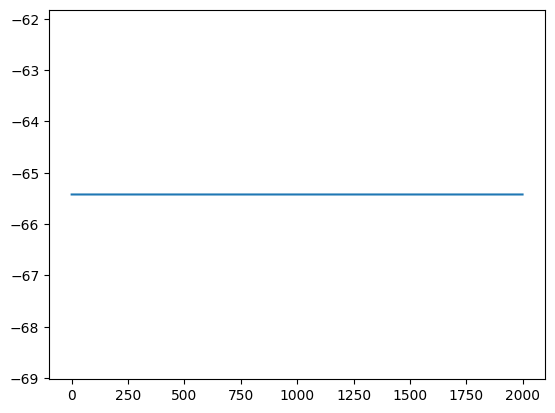

In [65]:
plt.plot(history_state[0].logdensity)

In [66]:
RWState = history_state[0]
positions = RWState.position
df = pd.DataFrame(positions)

In [67]:
df

,M_MN,M_NFW,Mtot,a_MN,a_Plummer,r_s,t_end
0,8.442244e+10,2.451057e+11,17816.687500,1.269185,0.005091,28.632391,2.310661
1,8.445110e+10,2.446952e+11,17808.986328,1.289076,0.004965,28.531826,2.312650
2,8.455170e+10,2.446337e+11,17800.380859,1.272033,0.004898,28.520863,2.297806
3,8.473883e+10,2.454766e+11,17807.039062,1.287737,0.004877,28.668970,2.314624
4,8.480548e+10,2.437786e+11,17794.285156,1.284688,0.004853,28.620232,2.323280
...,...,...,...,...,...,...,...
1995,8.661000e+10,2.895750e+11,17816.951172,1.357042,0.002561,30.975388,2.361756
1996,8.673450e+10,2.884104e+11,17808.947266,1.350011,0.002674,31.027494,2.350384
1997,8.673814e+10,2.889076e+11,17809.458984,1.364657,0.002714,30.947954,2.353091
1998,8.692189e+10,2.889436e+11,17799.710938,1.364624,0.002560,30.985455,2.347279


In [68]:
history_state[0].position

{'M_MN': Array([8.4422443e+10, 8.4451099e+10, 8.4551705e+10, ..., 8.6738141e+10,
        8.6921888e+10, 8.6842065e+10], dtype=float32),
 'M_NFW': Array([2.4510574e+11, 2.4469515e+11, 2.4463370e+11, ..., 2.8890762e+11,
        2.8894364e+11, 2.8942385e+11], dtype=float32),
 'Mtot': Array([17816.688, 17808.986, 17800.38 , ..., 17809.459, 17799.71 ,
        17797.45 ], dtype=float32),
 'a_MN': Array([1.2691846, 1.2890761, 1.2720331, ..., 1.3646568, 1.3646241,
        1.358472 ], dtype=float32),
 'a_Plummer': Array([0.00509099, 0.00496511, 0.00489763, ..., 0.00271399, 0.00256008,
        0.00267566], dtype=float32),
 'r_s': Array([28.632391, 28.531826, 28.520863, ..., 30.947954, 30.985455,
        31.202642], dtype=float32),
 't_end': Array([2.3106608, 2.31265  , 2.297806 , ..., 2.3530912, 2.347279 ,
        2.3522143], dtype=float32)}

Original samples: 1 chains × 2000 samples = 2000
  Chain 0: 1936/2000 accepted (96.8%)
📊 Total accepted samples: 1936/2000 (96.8%)
📈 Final samples for plotting: 1736
🎨 Creating corner plot...


Parameter $M_{MN}$ [M$_\odot$] in chain MCMC Posterior (Filtered) is not constrained
Parameter $M_{Plummer}$ [M$_\odot$] in chain MCMC Posterior (Filtered) is not constrained
Parameter $a_{MN}$ [kpc] in chain MCMC Posterior (Filtered) is not constrained
Parameter $a_{Plummer}$ [kpc] in chain MCMC Posterior (Filtered) is not constrained
Parameter $r_s$ [kpc] in chain MCMC Posterior (Filtered) is not constrained
Parameter $t_{end}$ [Gyr] in chain MCMC Posterior (Filtered) is not constrained


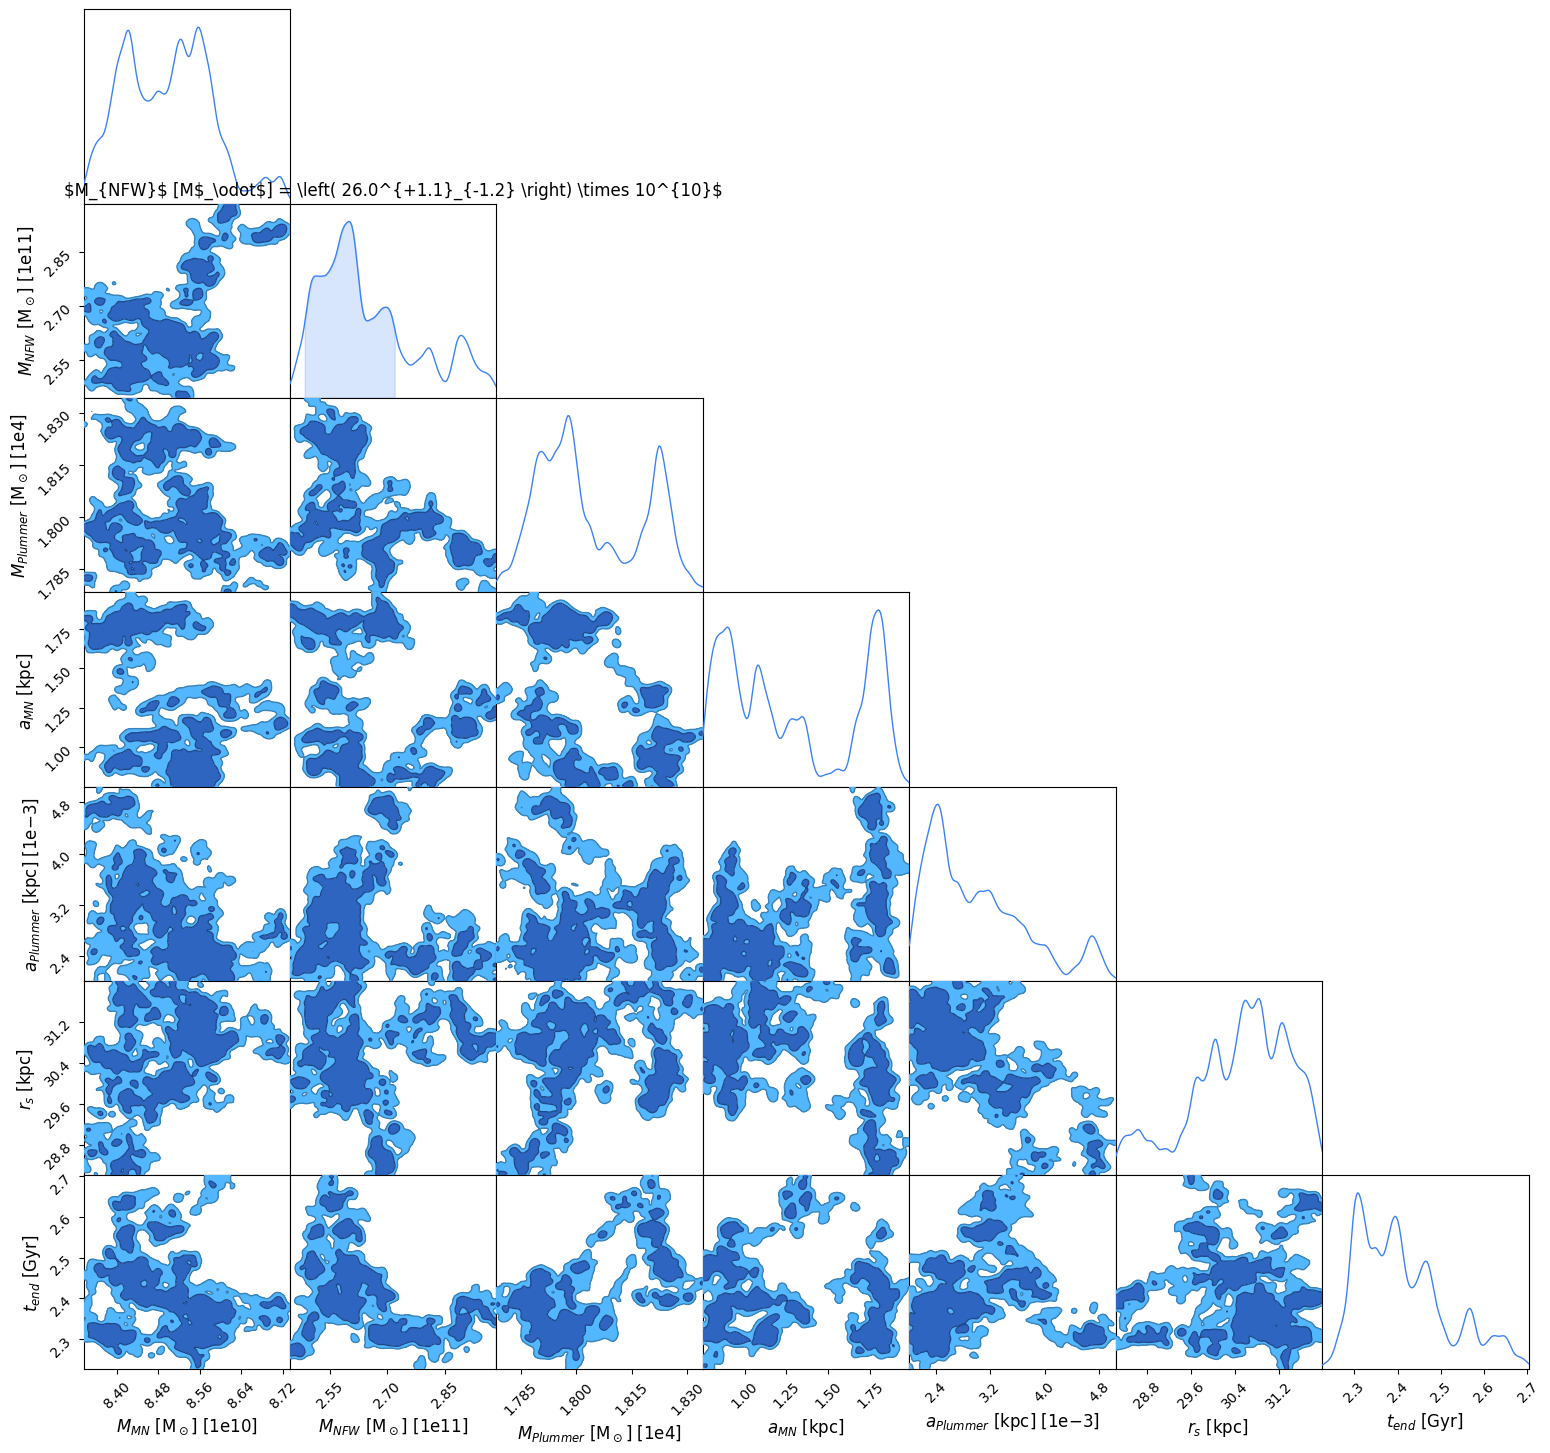


📊 MCMC Summary (filtered accepted samples):
Number of samples: 1736
Number of chains: 1

Parameter estimates (mean ± std):
------------------------------------------------------------
$M_{MN}$ [M$_\odot$]: 8.498087e+10 ± 8.514113e+08
True value          : 6.819390e+10
Bias (σ)            : 19.72
------------------------------------------------------------
$M_{NFW}$ [M$_\odot$]: 2.652414e+11 ± 1.318710e+10
True value          : 4.368332e+11
Bias (σ)            : -13.01
------------------------------------------------------------
$M_{Plummer}$ [M$_\odot$]: 1.803727e+04 ± 1.388431e+02
True value          : 1.122018e+04
Bias (σ)            : 49.10
------------------------------------------------------------
$a_{MN}$ [kpc]      : 1.286938e+00 ± 3.867073e-01
True value          : 3.000000e+00
Bias (σ)            : -4.43
------------------------------------------------------------
$a_{Plummer}$ [kpc] : 3.006619e-03 ± 7.349952e-04
True value          : 8.000000e-03
Bias (σ)            : -6.79

In [69]:
def convert_to_dataframe_filtered(positions_dict, is_accepted_mask):
    """Convert dictionary of arrays to DataFrame, filtering by acceptance. Works for single or multiple chains."""
    
    # Handle both single chain and multi-chain cases
    if len(positions_dict['t_end'].shape) == 1:
        # Single chain case: reshape to [1, num_samples]
        num_chains = 1
        num_samples = positions_dict['t_end'].shape[0]
        
        # Reshape all arrays to add chain dimension
        positions_reshaped = {}
        for param_name, values in positions_dict.items():
            positions_reshaped[param_name] = values.reshape(1, -1)
        
        # Reshape acceptance mask
        is_accepted_reshaped = is_accepted_mask.reshape(1, -1)
        
    else:
        # Multi-chain case: use as-is
        num_chains = positions_dict['t_end'].shape[0]
        num_samples = positions_dict['t_end'].shape[1]
        positions_reshaped = positions_dict
        is_accepted_reshaped = is_accepted_mask
    
    print(f"Original samples: {num_chains} chains × {num_samples} samples = {num_chains * num_samples}")
    
    all_samples = []
    
    for chain_id in range(num_chains):
        # Get acceptance mask for this chain
        chain_accepted = is_accepted_reshaped[chain_id, :]  # Boolean mask for this chain
        
        # Extract samples for this chain
        chain_data = {}
        for param_name, values in positions_reshaped.items():
            # Only keep accepted samples
            chain_data[param_name] = values[chain_id, chain_accepted]
        
        # Count accepted samples for this chain
        n_accepted = jnp.sum(chain_accepted)
        print(f"  Chain {chain_id}: {n_accepted}/{num_samples} accepted ({n_accepted/num_samples*100:.1f}%)")
        
        # Create DataFrame for this chain (only accepted samples)
        if n_accepted > 0:  # Only add if there are accepted samples
            df_chain = pd.DataFrame(chain_data)
            df_chain['chain_id'] = chain_id
            df_chain['original_sample_id'] = jnp.where(chain_accepted)[0]  # Track original indices
            
            all_samples.append(df_chain)
    
    if not all_samples:
        print("⚠️ Warning: No accepted samples found!")
        return pd.DataFrame()
    
    # Combine all chains
    combined_df = pd.concat(all_samples, ignore_index=True)
    total_accepted = len(combined_df)
    total_original = num_chains * num_samples
    
    print(f"📊 Total accepted samples: {total_accepted}/{total_original} ({total_accepted/total_original*100:.1f}%)")
    
    return combined_df

# Usage remains the same - works for both single and multiple chains
positions = history_state[0].position
is_accepted = history_state[1].is_accepted

# Convert with filtering (now works for single chain too)
df_all_filtered = convert_to_dataframe_filtered(positions, is_accepted)

# Rest of the code remains exactly the same
burn_in = 200  
thin_factor = 1  

if len(df_all_filtered) > 0:
    df_processed = df_all_filtered[
        (df_all_filtered['original_sample_id'] >= burn_in) & 
        (df_all_filtered['original_sample_id'] % thin_factor == 0)
    ].copy()
    
    # Remove metadata columns for plotting
    df_plot = df_processed.drop(['chain_id', 'original_sample_id'], axis=1)
    
    # Rename columns for nice LaTeX formatting
    df_plot.columns = ['$M_{MN}$ [M$_\odot$]', '$M_{NFW}$ [M$_\odot$]', '$M_{Plummer}$ [M$_\odot$]', '$a_{MN}$ [kpc]', '$a_{Plummer}$ [kpc]', '$r_s$ [kpc]', '$t_{end}$ [Gyr]']
    
    print(f"📈 Final samples for plotting: {len(df_plot)}")
    
    # Create ChainConsumer plot with true values
    from chainconsumer import Chain, ChainConsumer, Truth
    
    # Create Chain object
    chain = Chain(samples=df_plot, name="MCMC Posterior (Filtered)")
    
    # Create ChainConsumer object
    c = ChainConsumer()
    c.add_chain(chain)
    
    # Add true values
    true_values_dict = {
        '$M_{MN}$ [M$_\odot$]': 68_193_902_782.346756,
        '$M_{NFW}$ [M$_\odot$]': 4.3683325e11,
        '$M_{Plummer}$ [M$_\odot$]': 10**4.05,
        '$a_{MN}$ [kpc]': 3.0,
        '$a_{Plummer}$ [kpc]': 8.0 * 1e-3,
        '$r_s$ [kpc]': 16.0,
        '$t_{end}$ [Gyr]': 3.0,
    }
    
    truth = Truth(location=true_values_dict, name="True Parameters")
    c.add_truth(truth)
    
    # Create corner plot
    print("🎨 Creating corner plot...")
    fig = c.plotter.plot()
    plt.show()
    
    # Print summary statistics
    print("\n📊 MCMC Summary (filtered accepted samples):")
    print(f"Number of samples: {len(df_plot)}")
    print(f"Number of chains: {df_processed['chain_id'].nunique()}")
    
    # Calculate parameter statistics
    param_names = ['$M_{MN}$ [M$_\odot$]', '$M_{NFW}$ [M$_\odot$]', '$M_{Plummer}$ [M$_\odot$]', '$a_{MN}$ [kpc]', '$a_{Plummer}$ [kpc]', '$r_s$ [kpc]', '$t_{end}$ [Gyr]']
    
    print("\nParameter estimates (mean ± std):")
    print("-" * 60)
    for i, param in enumerate(param_names):
        col_name = df_plot.columns[i]
        mean_val = df_plot[col_name].mean()
        std_val = df_plot[col_name].std()
        true_val = list(true_values_dict.values())[i]
        
        print(f"{param:20s}: {mean_val:.6e} ± {std_val:.6e}")
        print(f"{'True value':20s}: {true_val:.6e}")
        print(f"{'Bias (σ)':20s}: {(mean_val - true_val) / std_val:.2f}")
        print("-" * 60)
    
else:
    print("❌ No samples available for plotting after filtering!")

# RMH Vectorized

In [70]:
from blackjax.util import run_inference_algorithm

# Fix: Create a proper random step function instead of passing an array
def random_step_fn(rng_key, position):
    """Generate random step proposals for each parameter."""
    # Use different step sizes for different parameters based on their scale
    step_sizes = jnp.array([
        0.1,    # t_end (Gyr) - smaller steps
        100.0,  # Mtot (Msun) - larger steps for large values
        0.001,  # a_Plummer (kpc) - very small steps
        1e10,    # M_NFW (Msun) - large steps for large values  
        1.0,    # r_s (kpc)
        1e9,    # M_MN (Msun) - large steps for large values
        0.2,    # a_MN (kpc)
    ])
    
    # Generate random steps
    random_steps = jax.random.normal(rng_key, shape=(7,)) * step_sizes
    
    # Convert to dictionary format to match your position format
    step_dict = {
        't_end': random_steps[0],
        'Mtot': random_steps[1], 
        'a_Plummer': random_steps[2],
        'M_NFW': random_steps[3],
        'r_s': random_steps[4],
        'M_MN': random_steps[5],
        'a_MN': random_steps[6]
    }
    return step_dict

@partial(jit, static_argnames=['num_chains'])
def run_inference_vmap(rng_key, num_chains=5):
    rng_keys = jax.random.split(rng_key, num_chains)
    intial_positions = jax.vmap(draw_from_prior)(rng_keys)
    # print(intial_positions)
    

    def extract_single_position(idx):
        """Extract a single position dict from the vmapped result."""
        return {key: values[idx] for key, values in intial_positions.items()}
    
    run_inference_vmap = lambda i: run_inference_algorithm(
        rng_key=rng_keys[i],
        inference_algorithm=blackjax.additive_step_random_walk(
                                    logdensity_fn=evaluate_log_posterior,
                                    random_step=random_step_fn
                                ),
        num_steps=10_000,
        initial_position=extract_single_position(i),
        progress_bar=False,
    )

    return jax.vmap(run_inference_vmap)(jnp.arange(num_chains))
  
print('start running chains')
history = run_inference_vmap(jax.random.PRNGKey(42), num_chains=2)

start running chains


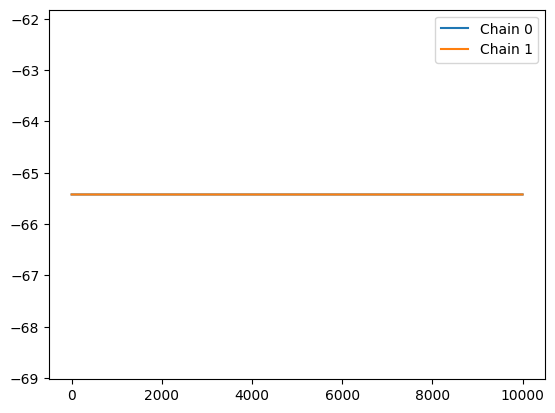

In [71]:
for i in range(history[1][0].logdensity.shape[0]):
    plt.plot(history[1][0].logdensity[i], label=f'Chain {i}')
    plt.legend()

In [72]:
history[1][1].is_accepted

Array([[False,  True,  True, ...,  True,  True,  True],
       [ True,  True, False, ...,  True,  True,  True]], dtype=bool)

Original samples: 2 chains × 10000 samples = 20000
  Chain 0: 8644/10000 accepted (86.4%)
  Chain 1: 8424/10000 accepted (84.2%)
📊 Total accepted samples: 17068/20000 (85.3%)
📈 Final samples for plotting: 868
🎨 Creating corner plot...


Parameter $M_{MN}$ [M$_\odot$] in chain MCMC Posterior (Filtered) is not constrained
Parameter $M_{NFW}$ [M$_\odot$] in chain MCMC Posterior (Filtered) is not constrained
Parameter $M_{Plummer}$ [M$_\odot$] in chain MCMC Posterior (Filtered) is not constrained
Parameter $r_s$ [kpc] in chain MCMC Posterior (Filtered) is not constrained
Parameter $t_{end}$ [Gyr] in chain MCMC Posterior (Filtered) is not constrained


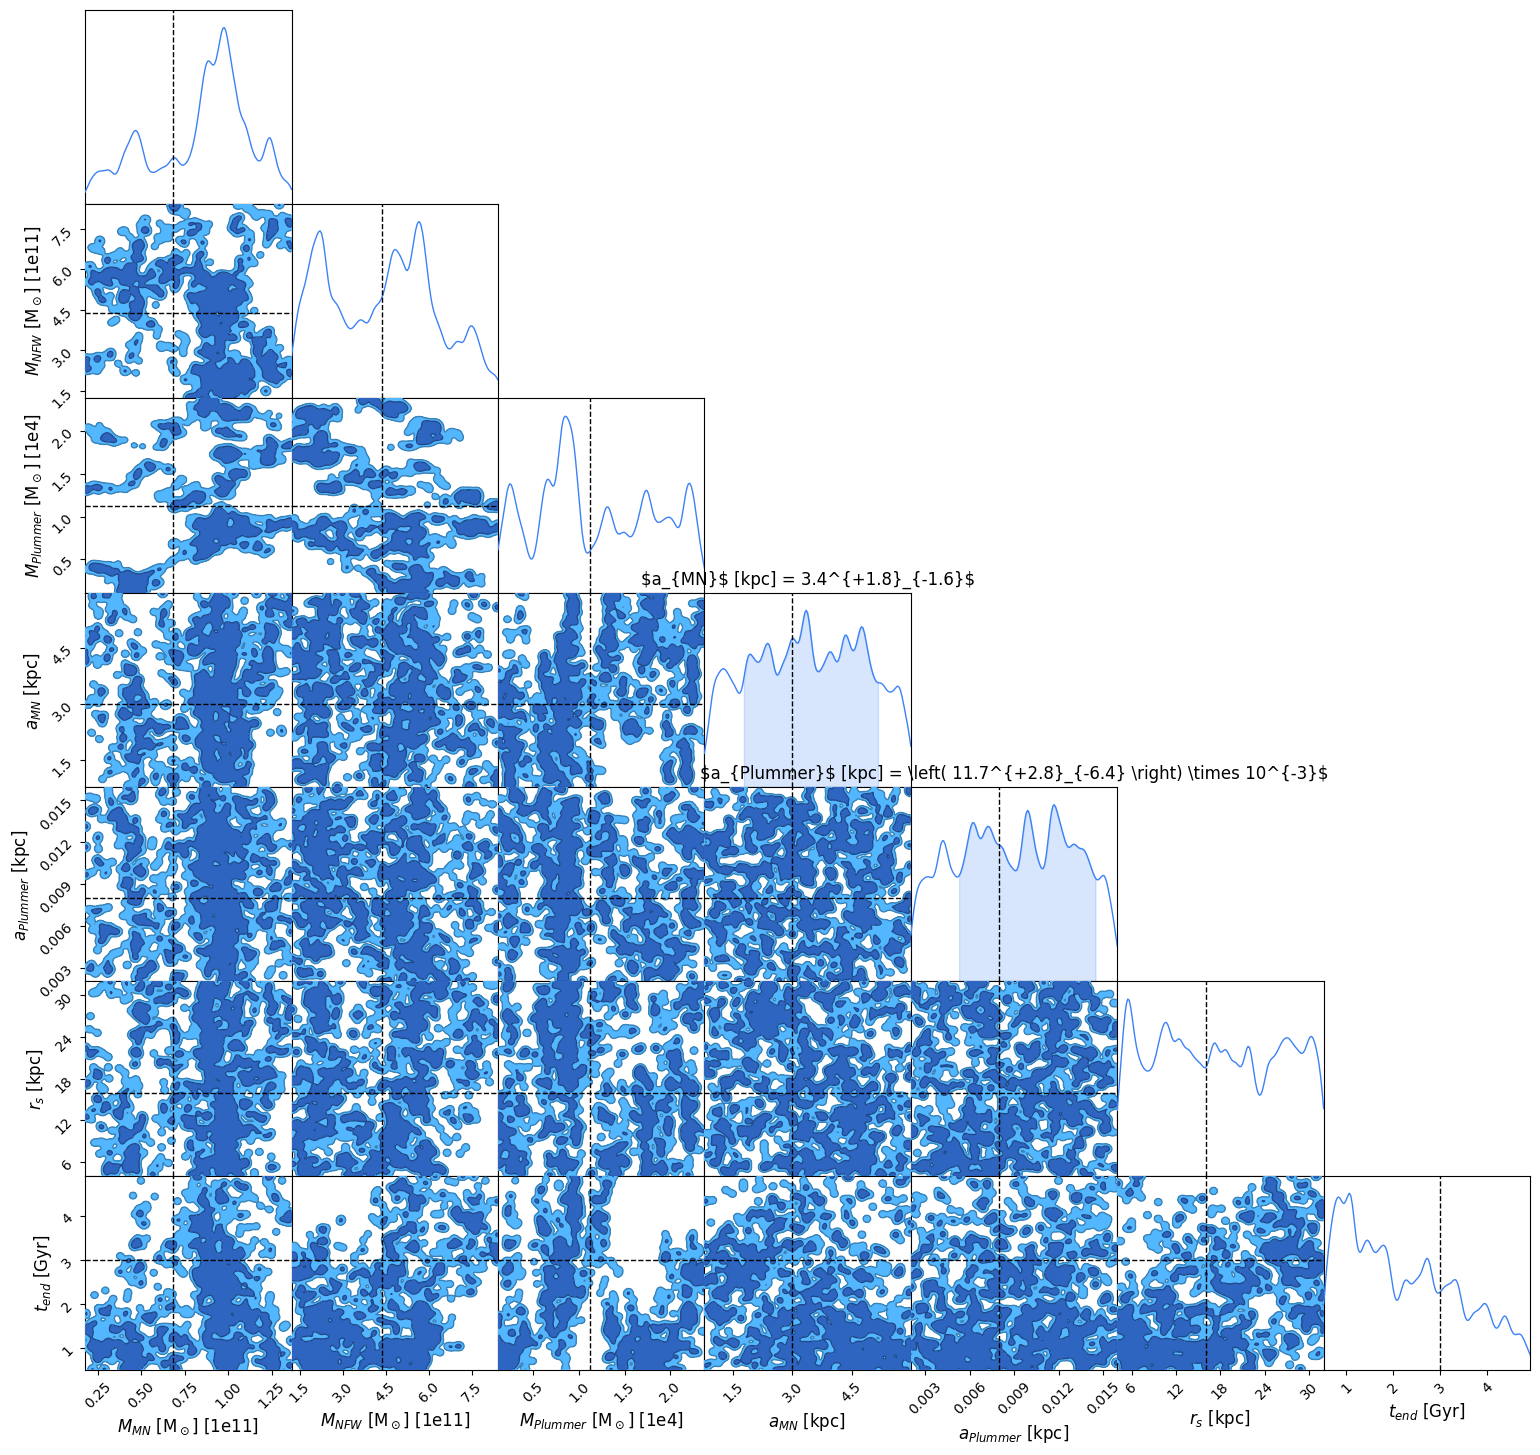


📊 MCMC Summary (filtered accepted samples):
Number of samples: 868
Number of chains: 2

Parameter estimates (mean ± std):
------------------------------------------------------------
$M_{MN}$ [M$_\odot$]: 8.415875e+10 ± 2.831945e+10
True value          : 3.000000e+00
Bias (σ)            : 2.97
------------------------------------------------------------
$M_{NFW}$ [M$_\odot$]: 4.397721e+11 ± 1.891486e+11
True value          : 1.122018e+04
Bias (σ)            : 2.33
------------------------------------------------------------
$M_{Plummer}$ [M$_\odot$]: 1.199087e+04 ± 6.482768e+03
True value          : 8.000000e-03
Bias (σ)            : 1.85
------------------------------------------------------------
$a_{MN}$ [kpc]      : 3.392586e+00 ± 1.403491e+00
True value          : 4.368332e+11
Bias (σ)            : -311247699968.00
------------------------------------------------------------
$a_{Plummer}$ [kpc] : 9.000673e-03 ± 3.777915e-03
True value          : 1.600000e+01
Bias (σ)            :

In [75]:
def convert_multichain_to_dataframe_filtered(positions_dict, is_accepted_mask):
    """Convert dictionary of [num_chains, num_samples] arrays to DataFrame, filtering by acceptance."""
    
    all_samples = []
    num_chains = positions_dict['t_end'].shape[0]
    num_samples = positions_dict['t_end'].shape[1]
    
    print(f"Original samples: {num_chains} chains × {num_samples} samples = {num_chains * num_samples}")
    
    for chain_id in range(num_chains):
        # Get acceptance mask for this chain
        chain_accepted = is_accepted_mask[chain_id, :]  # Boolean mask for this chain
        
        # Extract samples for this chain
        chain_data = {}
        for param_name, values in positions_dict.items():
            # Only keep accepted samples
            chain_data[param_name] = values[chain_id, chain_accepted]
        
        # Count accepted samples for this chain
        n_accepted = jnp.sum(chain_accepted)
        print(f"  Chain {chain_id}: {n_accepted}/{num_samples} accepted ({n_accepted/num_samples*100:.1f}%)")
        
        # Create DataFrame for this chain (only accepted samples)
        if n_accepted > 0:  # Only add if there are accepted samples
            df_chain = pd.DataFrame(chain_data)
            df_chain['chain_id'] = chain_id
            df_chain['original_sample_id'] = jnp.where(chain_accepted)[0]  # Track original indices
            
            all_samples.append(df_chain)
    
    if not all_samples:
        print("⚠️ Warning: No accepted samples found!")
        return pd.DataFrame()
    
    # Combine all chains
    combined_df = pd.concat(all_samples, ignore_index=True)
    total_accepted = len(combined_df)
    total_original = num_chains * num_samples
    
    print(f"📊 Total accepted samples: {total_accepted}/{total_original} ({total_accepted/total_original*100:.1f}%)")
    
    return combined_df

# Use the filtered conversion
positions = history[1][0].position
is_accepted = history[1][1].is_accepted

# Convert with filtering
df_all_filtered = convert_multichain_to_dataframe_filtered(positions, is_accepted)

# Apply additional burn-in and thinning if needed
burn_in = 5000  # Fewer since we already filtered by acceptance
thin_factor = 10  # Less thinning since we have fewer samples

if len(df_all_filtered) > 0:
    df_processed = df_all_filtered[
        (df_all_filtered['original_sample_id'] >= burn_in) & 
        (df_all_filtered['original_sample_id'] % thin_factor == 0)
    ].copy()
    
    # Remove metadata columns for plotting
    df_plot = df_processed.drop(['chain_id', 'original_sample_id'], axis=1)
    
    # Rename columns for nice LaTeX formatting
    df_plot.columns = ['$M_{MN}$ [M$_\odot$]', '$M_{NFW}$ [M$_\odot$]', '$M_{Plummer}$ [M$_\odot$]', '$a_{MN}$ [kpc]', '$a_{Plummer}$ [kpc]', '$r_s$ [kpc]', '$t_{end}$ [Gyr]']
    
    print(f"📈 Final samples for plotting: {len(df_plot)}")
    
    # Create ChainConsumer plot with true values
    from chainconsumer import Chain, ChainConsumer, Truth
    
    # Create Chain object
    chain = Chain(samples=df_plot, name="MCMC Posterior (Filtered)")
    
    # Create ChainConsumer object
    c = ChainConsumer()
    c.add_chain(chain)
    
    # Add true values
    true_values_dict = {
        '$t_{end}$ [Gyr]': 3.0,
        '$M_{Plummer}$ [M$_\odot$]': 10**4.05,
        '$a_{Plummer}$ [kpc]': 8.0 * 1e-3,
        '$M_{NFW}$ [M$_\odot$]': 4.3683325e11,
        '$r_s$ [kpc]': 16.0,
        '$M_{MN}$ [M$_\odot$]': 68_193_902_782.346756,
        '$a_{MN}$ [kpc]': 3.0
    }
    
    truth = Truth(location=true_values_dict, name="True Parameters")
    c.add_truth(truth)
    
    # Create corner plot
    print("🎨 Creating corner plot...")
    fig = c.plotter.plot()
    plt.show()
    
    # Print summary statistics
    print("\n📊 MCMC Summary (filtered accepted samples):")
    print(f"Number of samples: {len(df_plot)}")
    print(f"Number of chains: {df_processed['chain_id'].nunique()}")
    
    # Calculate parameter statistics
    param_names = ['$M_{MN}$ [M$_\odot$]', '$M_{NFW}$ [M$_\odot$]', '$M_{Plummer}$ [M$_\odot$]', '$a_{MN}$ [kpc]', '$a_{Plummer}$ [kpc]', '$r_s$ [kpc]', '$t_{end}$ [Gyr]']
    
    print("\nParameter estimates (mean ± std):")
    print("-" * 60)
    for i, param in enumerate(param_names):
        col_name = df_plot.columns[i]
        mean_val = df_plot[col_name].mean()
        std_val = df_plot[col_name].std()
        true_val = list(true_values_dict.values())[i]
        
        print(f"{param:20s}: {mean_val:.6e} ± {std_val:.6e}")
        print(f"{'True value':20s}: {true_val:.6e}")
        print(f"{'Bias (σ)':20s}: {(mean_val - true_val) / std_val:.2f}")
        print("-" * 60)
    
else:
    print("❌ No samples available for plotting after filtering!")

# Plotting from file

In [3]:
df_all_filtered = pd.read_csv('./mcmc_samples_filtered.csv')
df_all_filtered.head()

,M_MN,M_NFW,Mtot,a_MN,a_Plummer,r_s,t_end,chain_id,original_sample_id
0,5.395979e+10,2.062110e+11,3709.7593,4.447958,0.006794,30.481577,2.396865,0,1
1,5.460409e+10,2.077233e+11,3853.6567,4.386364,0.005564,29.913061,2.388930,0,2
2,5.339037e+10,2.138972e+11,3890.9148,4.312272,0.003677,28.205208,2.272749,0,3
3,5.389996e+10,2.202399e+11,3829.5234,4.341014,0.003422,28.936502,2.401712,0,4
4,5.394881e+10,2.223104e+11,3828.4734,4.201054,0.003790,28.779718,2.308783,0,5


📈 Final samples for plotting: 3079
🎨 Creating corner plot...


Parameter $M_{MN}$ [M$_\odot$] in chain MCMC Posterior (Filtered) is not constrained
Parameter $M_{NFW}$ [M$_\odot$] in chain MCMC Posterior (Filtered) is not constrained
Parameter $M_{Plummer}$ [M$_\odot$] in chain MCMC Posterior (Filtered) is not constrained
Parameter $a_{MN}$ [kpc] in chain MCMC Posterior (Filtered) is not constrained
Parameter $a_{Plummer}$ [kpc] in chain MCMC Posterior (Filtered) is not constrained
Parameter $r_s$ [kpc] in chain MCMC Posterior (Filtered) is not constrained
Parameter $t_{end}$ [Gyr] in chain MCMC Posterior (Filtered) is not constrained


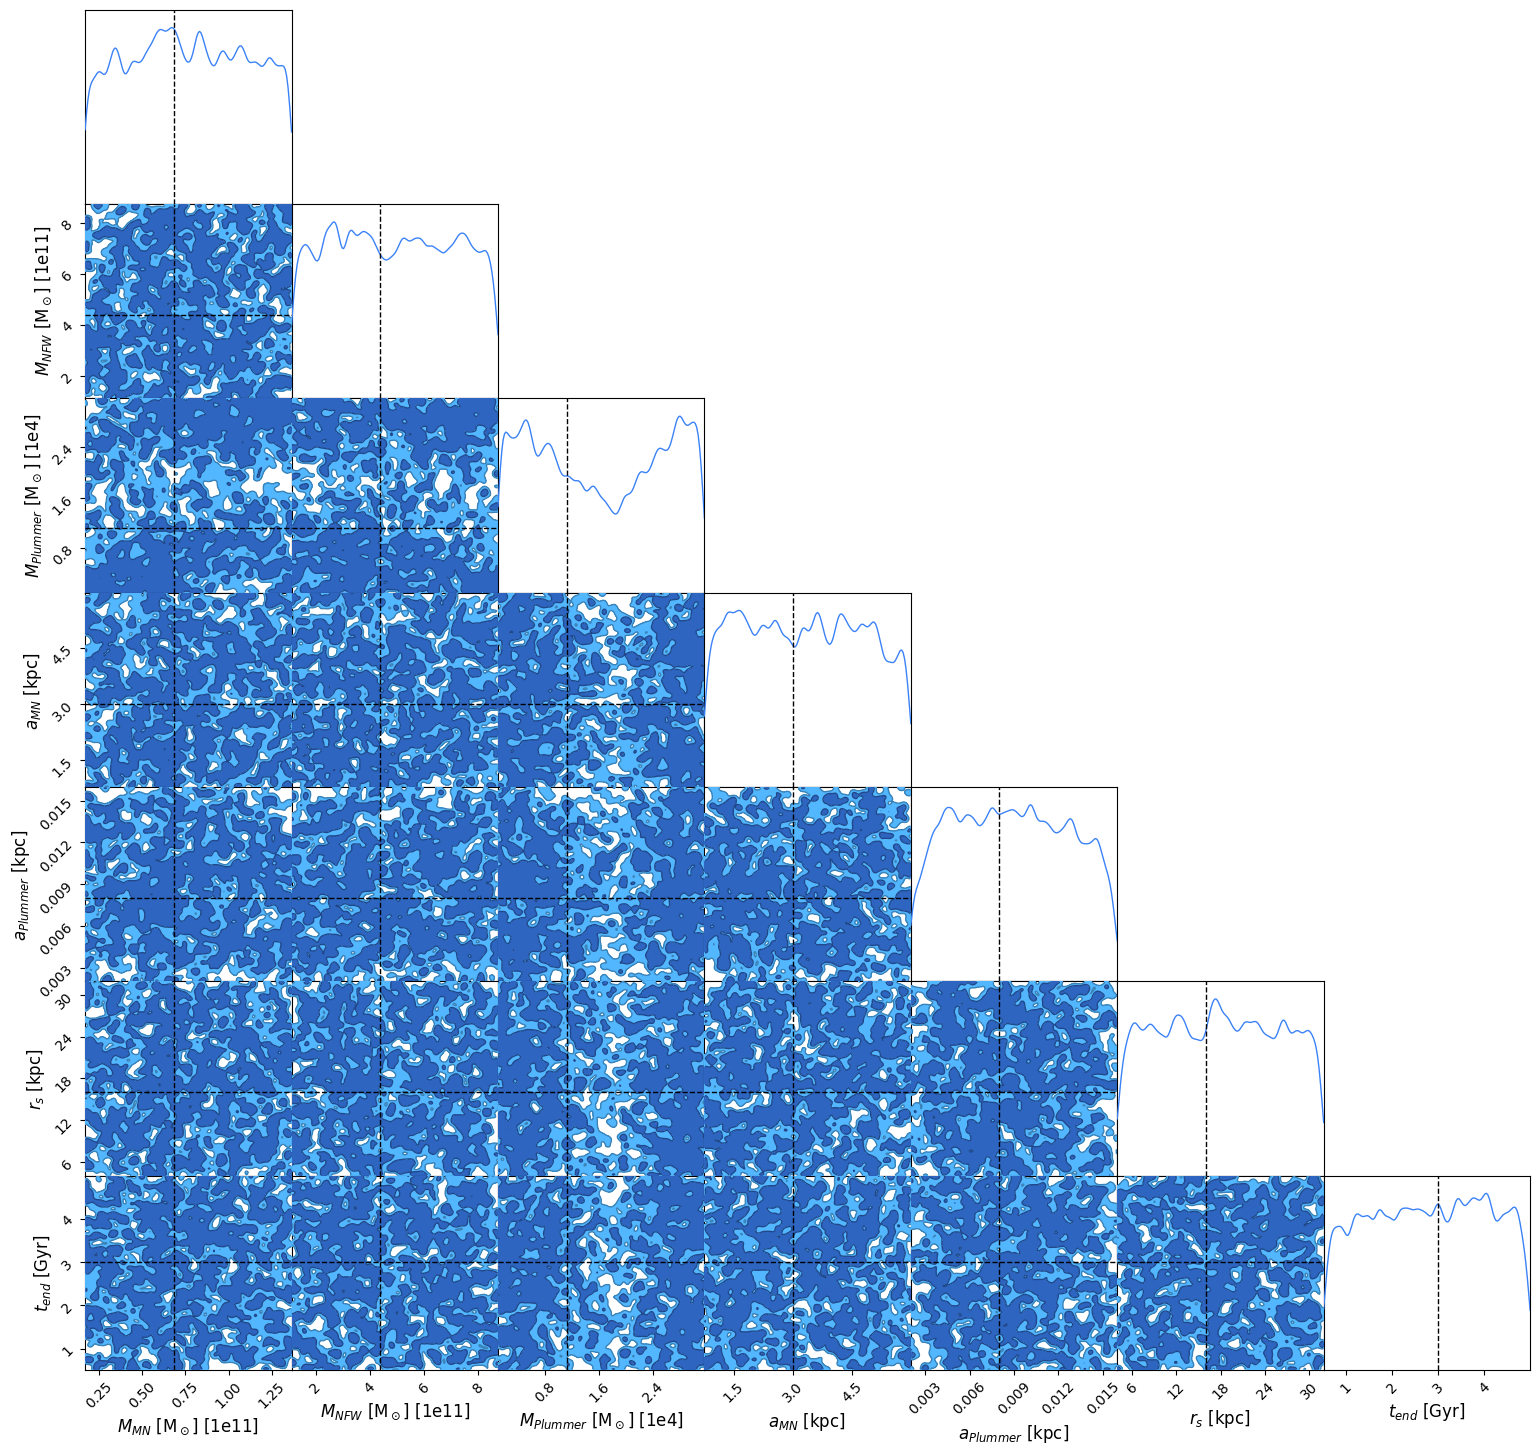


📊 MCMC Summary (filtered accepted samples):
Number of samples: 3079
Number of chains: 20

Parameter estimates (mean ± std):
------------------------------------------------------------
$M_{MN}$ [M$_\odot$]: 7.683858e+10 ± 3.360317e+10
True value          : 6.819390e+10
Bias (σ)            : 0.26
------------------------------------------------------------
$M_{NFW}$ [M$_\odot$]: 4.889703e+11 ± 2.174945e+11
True value          : 4.368332e+11
Bias (σ)            : 0.24
------------------------------------------------------------
$M_{Plummer}$ [M$_\odot$]: 1.625005e+04 ± 9.564209e+03
True value          : 1.122018e+04
Bias (σ)            : 0.53
------------------------------------------------------------
$a_{MN}$ [kpc]      : 3.312119e+00 ± 1.485367e+00
True value          : 3.000000e+00
Bias (σ)            : 0.21
------------------------------------------------------------
$a_{Plummer}$ [kpc] : 8.874842e-03 ± 3.784329e-03
True value          : 8.000000e-03
Bias (σ)            : 0.23
----

In [7]:
# Apply additional burn-in and thinning if needed
burn_in = 10_000  # Fewer since we already filtered by acceptance
thin_factor = 500  # Less thinning since we have fewer samples

if len(df_all_filtered) > 0:
    df_processed = df_all_filtered[
        (df_all_filtered['original_sample_id'] >= burn_in) & 
        (df_all_filtered['original_sample_id'] % thin_factor == 0)
    ].copy()
    
    # Remove metadata columns for plotting
    df_plot = df_processed.drop(['chain_id', 'original_sample_id'], axis=1)
    
    # Rename columns for nice LaTeX formatting
    df_plot.columns = ['$M_{MN}$ [M$_\odot$]', '$M_{NFW}$ [M$_\odot$]', '$M_{Plummer}$ [M$_\odot$]', '$a_{MN}$ [kpc]', '$a_{Plummer}$ [kpc]', '$r_s$ [kpc]', '$t_{end}$ [Gyr]']
    
    print(f"📈 Final samples for plotting: {len(df_plot)}")
    
    # Create ChainConsumer plot with true values
    from chainconsumer import Chain, ChainConsumer, Truth
    
    # Create Chain object
    chain = Chain(samples=df_plot, name="MCMC Posterior (Filtered)")
    
    # Create ChainConsumer object
    c = ChainConsumer()
    c.add_chain(chain)
    
    # Add true values
    true_values_dict = {
        '$M_{MN}$ [M$_\odot$]': 68_193_902_782.346756,
        '$M_{NFW}$ [M$_\odot$]': 4.3683325e11,
        '$M_{Plummer}$ [M$_\odot$]': 10**4.05,
        '$a_{MN}$ [kpc]': 3.0,
        '$a_{Plummer}$ [kpc]': 8.0 * 1e-3,
        '$r_s$ [kpc]': 16.0,
        '$t_{end}$ [Gyr]': 3.0,
    }
    
    truth = Truth(location=true_values_dict, name="True Parameters")
    c.add_truth(truth)
    
    # Create corner plot
    print("🎨 Creating corner plot...")
    fig = c.plotter.plot()
    plt.show()
    
    # Print summary statistics
    print("\n📊 MCMC Summary (filtered accepted samples):")
    print(f"Number of samples: {len(df_plot)}")
    print(f"Number of chains: {df_processed['chain_id'].nunique()}")
    
    # Calculate parameter statistics
    param_names = ['$M_{MN}$ [M$_\odot$]', '$M_{NFW}$ [M$_\odot$]', '$M_{Plummer}$ [M$_\odot$]', '$a_{MN}$ [kpc]', '$a_{Plummer}$ [kpc]', '$r_s$ [kpc]', '$t_{end}$ [Gyr]']
    
    print("\nParameter estimates (mean ± std):")
    print("-" * 60)
    for i, param in enumerate(param_names):
        col_name = df_plot.columns[i]
        mean_val = df_plot[col_name].mean()
        std_val = df_plot[col_name].std()
        true_val = list(true_values_dict.values())[i]
        
        print(f"{param:20s}: {mean_val:.6e} ± {std_val:.6e}")
        print(f"{'True value':20s}: {true_val:.6e}")
        print(f"{'Bias (σ)':20s}: {(mean_val - true_val) / std_val:.2f}")
        print("-" * 60)
    
else:
    print("❌ No samples available for plotting after filtering!")

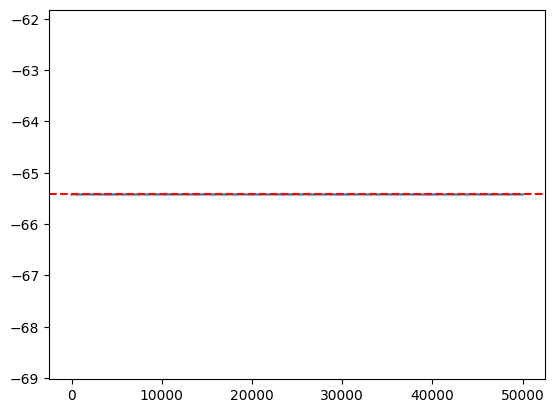

In [6]:
chains_logdensity = np.load('./mcmc_logdensity.npy')
plt.plot(chains_logdensity[4], label='Chain 0')
plt.axhline(np.mean(chains_logdensity[4]), color='red', linestyle='--', label='Max Log-Likelihood')
# plt.xscale('log')